# Exercise 1

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6457 - loss: 0.9793 - val_accuracy: 0.7489 - val_loss: 0.6781
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7698 - loss: 0.6234 - val_accuracy: 0.7885 - val_loss: 0.5867
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.7946 - loss: 0.5637 - val_accuracy: 0.8022 - val_loss: 0.5505
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8095 - loss: 0.5284 - val_accuracy: 0.8159 - val_loss: 0.5148
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8228 - loss: 0.4981 - val_accuracy: 0.8259 - val_loss: 0.4886
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8311 - loss: 0.4742 - val_accuracy: 0.8357 - val_loss: 0.4653
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8382 - loss: 0.4536 - val_accuracy: 0.8398 - val_loss: 0.4514
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8437 - loss: 0

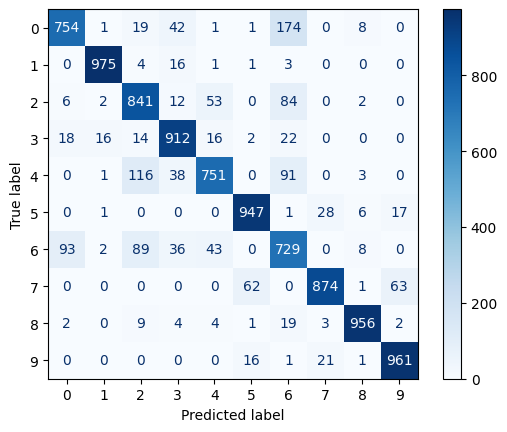

In [5]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report,ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Rescaling
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Input

testing_data = pd.read_csv('fashion-mnist_test.csv')
training_data = pd.read_csv('fashion-mnist_train.csv')
x_train = training_data.drop('label', axis=1).values
y_train = training_data['label'].values
x_test = testing_data.drop('label', axis=1).values
y_test = testing_data['label'].values
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
input_dim = (28, 28, 1)
model = Sequential([
    Input(shape=input_dim),
    Rescaling(1.0 / 255),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=30, verbose=1, validation_data=(x_test, y_test))
y_pred = model.predict(x_test, verbose=0)
y_test = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred, axis=1)
print('Performance indicators')
precision = precision_score(y_test, y_pred, average="weighted")
print("Precision score: ",precision)
recall= recall_score(y_test, y_pred, average="weighted")
print("Recall score: ",recall)
conf_matrix=confusion_matrix(y_test, y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap="Blues")